# PB03 — Read↔Img Similarity come Metrica di BCI Literacy

**Ipotesi**: i soggetti BCI-literate hanno pattern EEG simili tra `word_read` e `word_img` per la stessa parola.
Nei soggetti illiterate, l'immaginazione non attiva le stesse reti della lettura.

**Metrica**: correlazione di Pearson tra `word_read` e `word_img` (stessa parola, stesso soggetto),
mediata su tutte le parole → un singolo score di "fedeltà immaginativa" per soggetto.

**Validazione**: correla questo score con la `bacc` del soggetto nel task imagined speech.

In [1]:
from pathlib import Path
import json

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents) if (p / '.git').exists()),
    Path().resolve()
)

DATA_ROOT   = project_root / 'data' / 'raw_csv' / 'training_set'
CONFIGS     = project_root / 'configs' / 'label_schemes'
SFREQ = 256
N_CHAN = 61
N_SAMP = 384

with open(CONFIGS / 'label2idx.json') as f:
    word2idx = json.load(f)
WORDS = sorted(word2idx.keys())
print(f'Parole: {len(WORDS)} | DATA_ROOT: {DATA_ROOT}')

Parole: 110 | DATA_ROOT: /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
print('Import OK')

Import OK


In [3]:
# ============================================================
# CARICA BACC PER SOGGETTO — da PB00 o da W&B
# ============================================================
import pandas as pd

BACC_CSV = project_root / 'data' / 'interim' / 'subject_bacc_pipelineB.csv'

if BACC_CSV.exists():
    _df_bacc = pd.read_csv(BACC_CSV).dropna(subset=['bacc'])
    SUBJ_BACC = dict(zip(_df_bacc['subj_id'].astype(int), _df_bacc['bacc']))
    print(f'Caricati {len(SUBJ_BACC)} soggetti da {BACC_CSV.name}')
else:
    print('WARNING: subject_bacc_pipelineB.csv non trovato. Esegui PB00 prima.')
    SUBJ_BACC = {}

Caricati 91 soggetti da subject_bacc_pipelineB.csv


In [4]:
# ============================================================
# CALCOLA READ↔IMG SIMILARITY PER SOGGETTO  (lettura robusta)
# ============================================================

def _read_csv_safe(f: Path):
    """Legge un CSV (61,384); None se mancante/vuoto/forma sbagliata."""
    try:
        if not f.exists() or f.stat().st_size == 0:
            return None
        x = pd.read_csv(f, header=None).values.astype(np.float32)
    except Exception:
        return None
    return x if x.shape == (N_CHAN, N_SAMP) else None


def read_img_similarity(subj_id: int, data_root: Path) -> float:
    """
    Per ogni parola: media delle epoche read e img su tutte le sessioni.
    Correlazione di Pearson tra i due segnali medi (flatten), mediata sulle parole.
    """
    corrs = []
    sess_dirs = sorted(data_root.glob(f'P{subj_id:03d}_S*'))
    if not sess_dirs:
        return np.nan
    for word in WORDS:
        imgs, reads = [], []
        for sess_dir in sess_dirs:
            xi = _read_csv_safe(sess_dir / f'{word}_img.csv')
            if xi is not None:
                imgs.append(xi)
            xr = _read_csv_safe(sess_dir / f'{word}_read.csv')
            if xr is not None:
                reads.append(xr)
        if not imgs or not reads:
            continue
        mean_img  = np.mean(imgs, axis=0).flatten()   # (61*384,)
        mean_read = np.mean(reads, axis=0).flatten()
        r, _ = stats.pearsonr(mean_img, mean_read)
        corrs.append(r)
    return float(np.mean(corrs)) if corrs else np.nan


# Test su un soggetto
sim = read_img_similarity(0, DATA_ROOT)
print(f'P000 read↔img similarity: {sim:.4f}')

P000 read↔img similarity: -0.0092


In [5]:
# ============================================================
# CALCOLA PER TUTTI I SOGGETTI
# ============================================================

all_subj = sorted(set(
    int(d.name.split('_')[0][1:]) for d in DATA_ROOT.iterdir() if d.is_dir()
))

similarities, subj_ids = [], []
for sid in tqdm(all_subj, desc='Soggetti'):
    sim = read_img_similarity(sid, DATA_ROOT)
    similarities.append(sim)
    subj_ids.append(sid)

df = pd.DataFrame({'subj': subj_ids, 'read_img_sim': similarities})
df['bacc'] = df['subj'].map(SUBJ_BACC)
print(df.describe())
print(f'\nSoggetti con similarity calcolata: {df["read_img_sim"].notna().sum()}')

Soggetti:   0%|          | 0/91 [00:00<?, ?it/s]

           subj  read_img_sim       bacc
count  91.00000     91.000000  91.000000
mean   45.00000      0.001899   0.255280
std    26.41338      0.023947   0.035745
min     0.00000     -0.069770   0.172950
25%    22.50000     -0.007189   0.234413
50%    45.00000     -0.001644   0.252796
75%    67.50000      0.006082   0.277041
max    90.00000      0.115823   0.367605

Soggetti con similarity calcolata: 91


Read↔img similarity — n=91  media=0.002  mediana=-0.002  range=[-0.070, 0.116]
(NB: img è il segnale più debole — vedi PB02 — quindi la similarità è in parte dominata dal rumore)

Spearman(similarity, bAcc) = -0.112  |  p_param = 0.2905  |  p_permutazione (two-sided) = 0.2853   (n=91)
→ se non significativo: la fedeltà read↔img NON predice la proficiency (coerente con PB01 e col soffitto informativo).


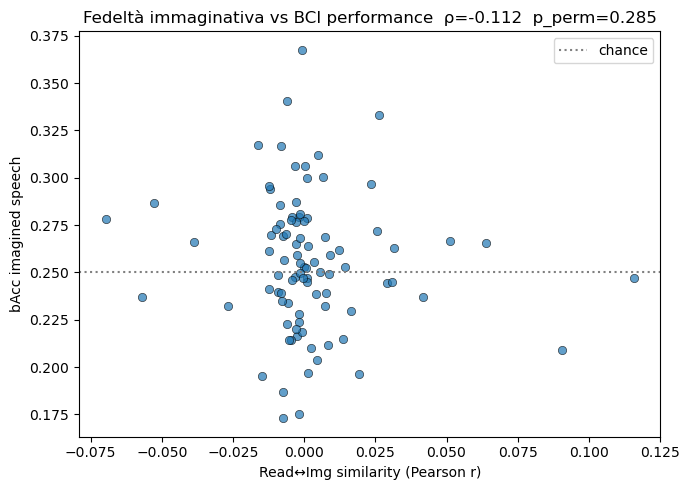

In [6]:
# ============================================================
# (1) DESCRITTIVO della similarity   (2) CORRELAZIONE con bAcc + null per permutazione
# ============================================================
sim_all = df['read_img_sim'].dropna()
print(f'Read↔img similarity — n={len(sim_all)}  media={sim_all.mean():.3f}  '
      f'mediana={sim_all.median():.3f}  range=[{sim_all.min():.3f}, {sim_all.max():.3f}]')
print('(NB: img è il segnale più debole — vedi PB02 — quindi la similarità è in parte dominata dal rumore)\n')

df_valid = df.dropna(subset=['read_img_sim', 'bacc'])

if len(df_valid) > 5:
    s = df_valid['read_img_sim'].values
    b = df_valid['bacc'].values
    rho, p = stats.spearmanr(s, b)

    # null per permutazione (two-sided), coerente con PB01
    rng = np.random.default_rng(42); N_PERM = 5000
    null = np.array([stats.spearmanr(s, rng.permutation(b)).correlation for _ in range(N_PERM)])
    p_perm = (np.sum(np.abs(null) >= abs(rho)) + 1) / (N_PERM + 1)

    print(f'Spearman(similarity, bAcc) = {rho:.3f}  |  p_param = {p:.4f}  |  '
          f'p_permutazione (two-sided) = {p_perm:.4f}   (n={len(df_valid)})')
    print('→ se non significativo: la fedeltà read↔img NON predice la proficiency '
          '(coerente con PB01 e col soffitto informativo).')

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(s, b, alpha=0.7, edgecolors='k', linewidths=0.5)
    ax.axhline(0.25, color='grey', ls=':', label='chance')
    ax.set_xlabel('Read↔Img similarity (Pearson r)')
    ax.set_ylabel('bAcc imagined speech')
    ax.set_title(f'Fedeltà immaginativa vs BCI performance  ρ={rho:.3f}  p_perm={p_perm:.3f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(project_root / 'figures' / 'PB03_readimg_similarity_vs_bacc.png', dpi=150)
    plt.show()
else:
    print('SUBJ_BACC insufficiente per la correlazione — esegui prima PB00.')

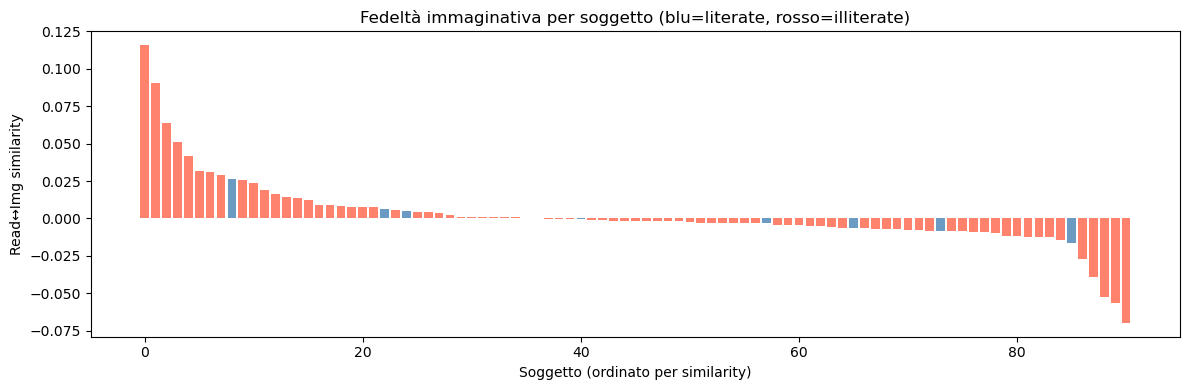

In [7]:
# ============================================================
# DISTRIBUZIONE SIMILARITY PER SOGGETTO
# ============================================================

df_sorted = df.sort_values('read_img_sim', ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue' if not np.isnan(b) and b > 0.30 else 'tomato'
          for b in df_sorted['bacc']]
ax.bar(range(len(df_sorted)), df_sorted['read_img_sim'], color=colors, alpha=0.8)
ax.set_xlabel('Soggetto (ordinato per similarity)')
ax.set_ylabel('Read↔Img similarity')
ax.set_title('Fedeltà immaginativa per soggetto (blu=literate, rosso=illiterate)')
plt.tight_layout()
plt.savefig(project_root / 'figures' / 'PB03_similarity_per_subject.png', dpi=150)
plt.show()